In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Load Data

In [ ]:
mall_df = pd.read_csv('/content/Mall_Customers.csv')

#Melihat Iinformasi Dataset

In [ ]:
mall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
mall_df = mall_df.drop('CustomerID', axis=1)

In [ ]:
mall_df.head(5)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
mall_df['Genre'].value_counts()

,count
Genre,
Female,112
Male,88


In [ ]:
mall_df.isna().sum()

,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
mall_df.duplicated().sum()

np.int64(0)

In [ ]:
mall_df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


#Data Analysis

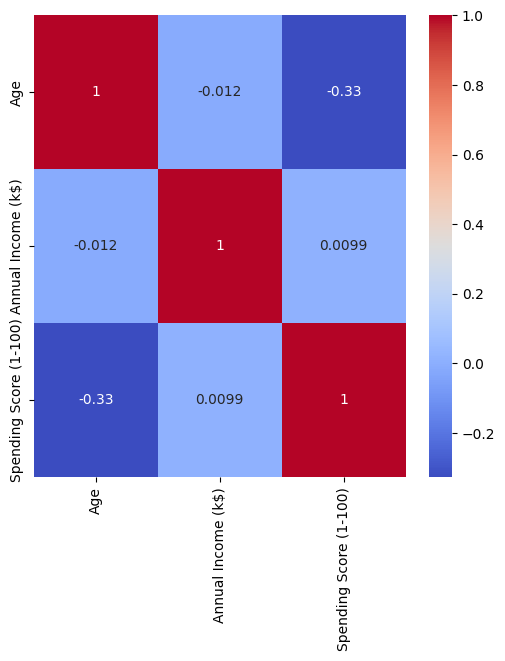

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(mall_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

- Age vs Annual Income   : korelasi lemah (~-0.01)
- Age vs Spending Score  : korelasi negatif lemah (~-0.33)
  → pelanggan lebih tua cenderung skor belanja lebih rendah
- Annual Income vs Spending Score: korelasi mendekati 0 (~0.01)

In [ ]:
num_col = mall_df.select_dtypes(include='number').columns

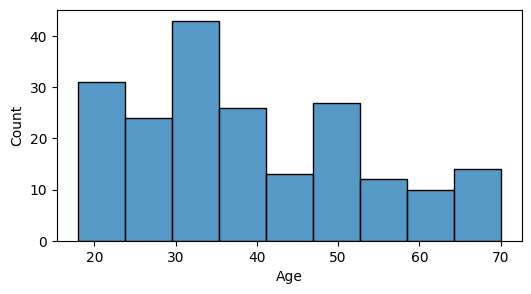

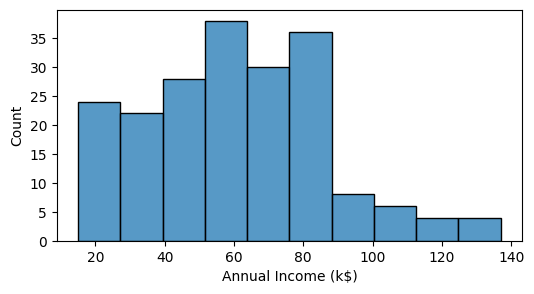

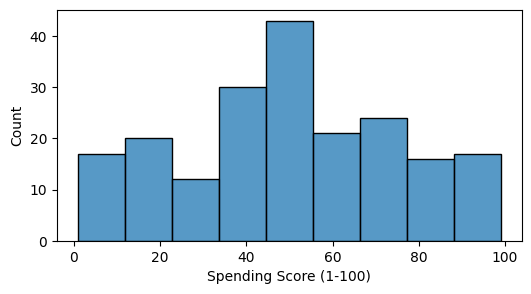

In [ ]:
for num in num_col:
    plt.figure(figsize=(6,3))
    sns.histplot(data = mall_df, x = num)

Interpretasi tiap histogram:
Age:
- Distribusi agak right-skewed (miring ke kanan)
- Pelanggan terbanyak berusia 20–40 tahun
Annual Income (k$):
- Distribusi relatif merata dengan sedikit puncak di kisaran 50k – 80k
Spending Score (1-100):
- Distribusi cukup merata (hampir seragam)
- Pelanggan tersebar di berbagai tingkat pengeluaran

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

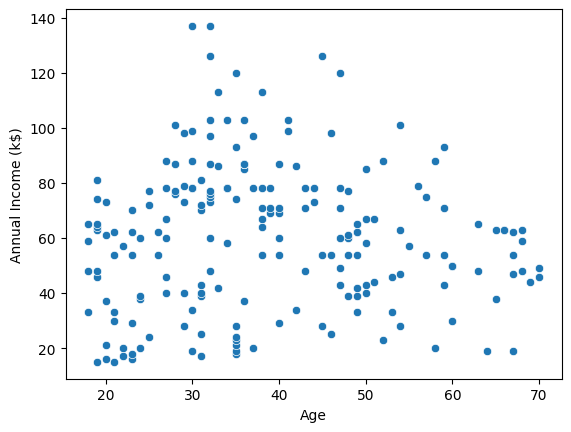

In [ ]:
sns.scatterplot(x = 'Age', y = 'Annual Income (k$)', data = mall_df)

 Insight:
- Tidak terlihat pola linear yang jelas
- Pelanggan dari semua kelompok usia memiliki rentang pendapatan beragam
- Pelanggan muda (< 30) maupun tua memiliki pendapatan tinggi dan rendah

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

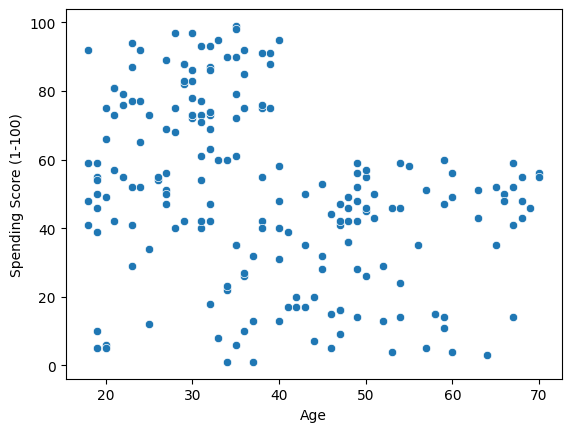

In [ ]:
sns.scatterplot(x = 'Age', y = 'Spending Score (1-100)', data = mall_df)

Insight:
- Ada kecenderungan: pelanggan lebih muda memiliki skor belanja lebih
tinggi dan lebih beragam, sementara pelanggan tua cenderung lebih rendah
- Korelasi negatif lemah terlihat secara visual

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

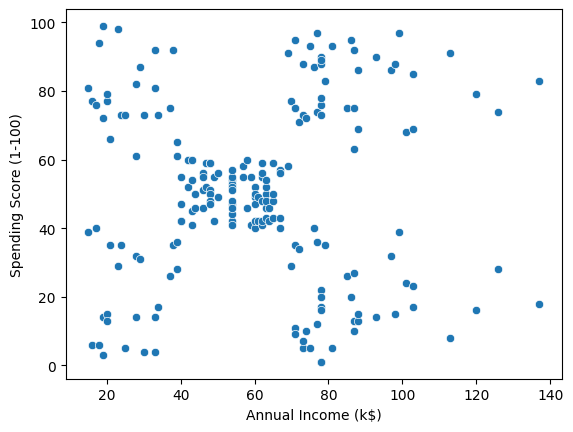

In [ ]:
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', data = mall_df)

 Insight:
- Terlihat 5 kluster yang menarik:
    1. Pendapatan rendah, skor belanja rendah
    2. Pendapatan rendah, skor belanja tinggi
    3. Pendapatan sedang, skor belanja sedang
    4. Pendapatan tinggi, skor belanja rendah
    5. Pendapatan tinggi, skor belanja tinggi  ← "target utama"
- Ini memberi sinyal kuat bahwa data ini cocok untuk K-Means Clustering

/tmp/ipykernel_494/2777328952.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=mall_df[column], palette='viridis')


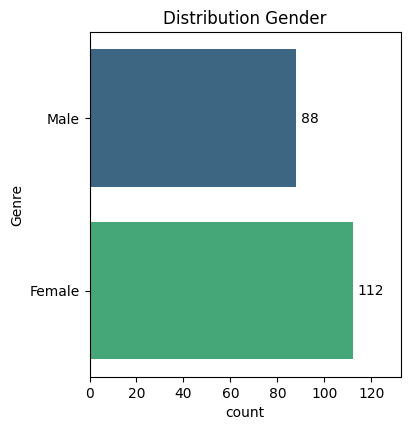

In [ ]:
cat_features = mall_df.select_dtypes(include=[object])

plt.figure(figsize=(14, 8))
for i, column in enumerate(cat_features.columns, 1):
    plt.subplot(2, 4, i)
    ax = sns.countplot(y=mall_df[column], palette='viridis')
    ax.set_xlim(0, ax.get_xlim()[1] + 15)
    plt.title(f'Distribution Gender')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}',
                    (p.get_width() + 2, p.get_y() + p.get_height()/2),
                    va='center')

plt.tight_layout()
plt.show()

Insight:
- 56% pelanggan adalah perempuan, 44% laki-laki
- Perempuan mendominasi sebagai pelanggan utama mall

/tmp/ipykernel_494/1709255063.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_494/1709255063.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_494/1709255063.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


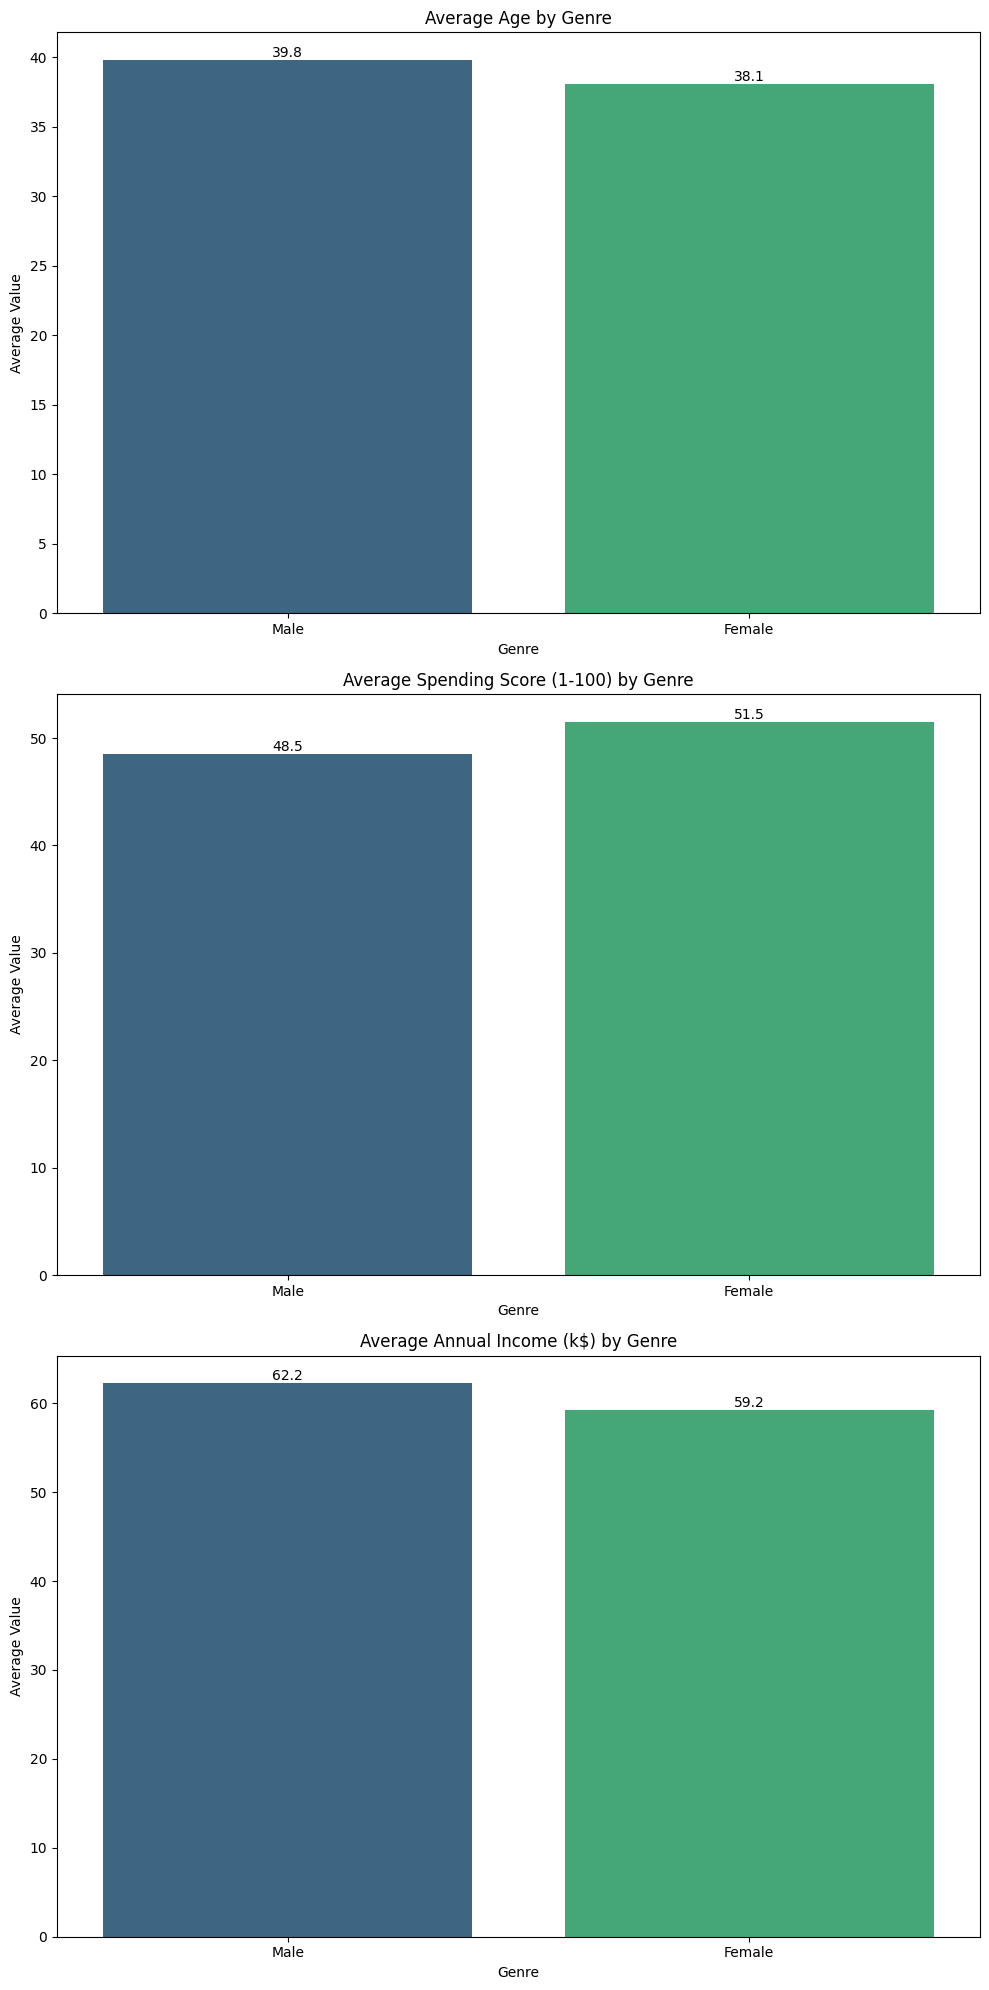

In [ ]:
def average_plot(features, df, segment_feature):
    fig, ax = plt.subplots(len(features), 1, figsize=(10, 20))

    for i, feature in enumerate(features):
        sns.barplot(
            data=df,
            x=segment_feature,
            y=feature,
            estimator=np.mean,
            errorbar=None,
            ax=ax[i],
            palette="viridis"
        )

        ax[i].set_title(f'Average {feature} by {segment_feature}')
        ax[i].set_ylabel('Average Value')
        ax[i].set_xlabel(segment_feature)

        for p in ax[i].patches:
            value = p.get_height()
            ax[i].annotate(f'{value:.1f}',
                           (p.get_x() + p.get_width() / 2, value),
                           ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

average_plot(
    features=[
        'Age',
        'Spending Score (1-100)',
        'Annual Income (k$)'

    ],
    df=mall_df,
    segment_feature="Genre"
)

Insight yang diharapkan:
- Rata-rata usia: Female & Male hampir sama (~38-39 tahun)
- Rata-rata Spending Score: Female sedikit lebih tinggi dari Male
- Rata-rata Annual Income  : Female & Male relatif mirip (~$59-62k)

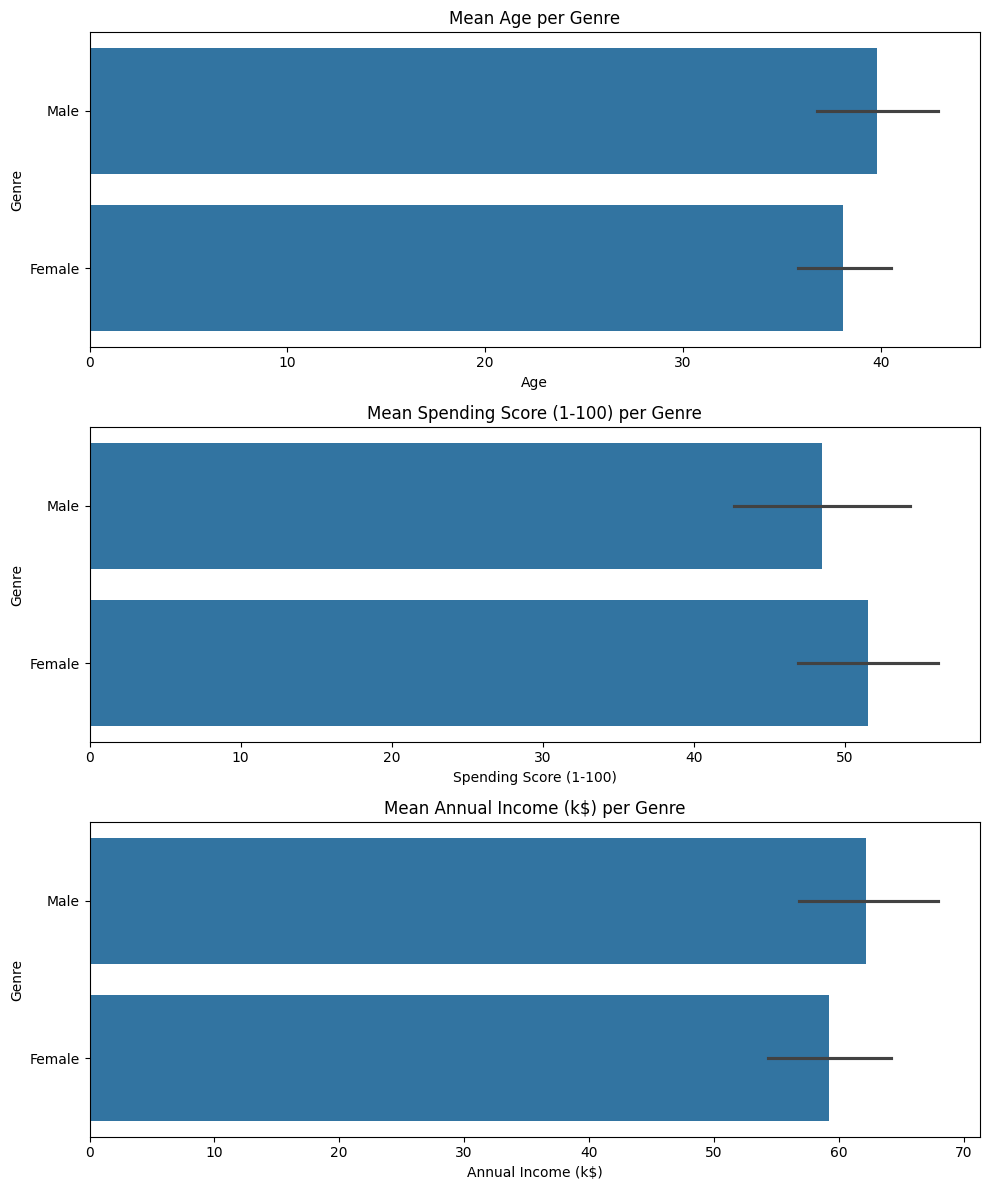

              Age  Spending Score (1-100)  Annual Income (k$)
Genre                                                        
Female  38.098214               51.526786           59.250000
Male    39.806818               48.511364           62.227273


In [ ]:
def mean_plot(features, df, segment_feature):
    fig, ax = plt.subplots(len(features), 1, figsize=(10, 12))

    for i, feature in enumerate(features):
        sns.barplot(
            data=df,
            x=feature,
            y=segment_feature,
            estimator=np.mean,
            ax=ax[i]
        )
        ax[i].set_title(f"Mean {feature} per {segment_feature}")

    plt.tight_layout()
    plt.show()

mean_plot(
    features=[
        'Age',
        'Spending Score (1-100)',
        'Annual Income (k$)'
    ],
    df=mall_df,
    segment_feature="Genre"
)
mean = mall_df.groupby('Genre')[['Age', 'Spending Score (1-100)', 'Annual Income (k$)']].mean()
print(mean)

RINGKASAN TEMUAN DATA ANALYSIS
1. Dataset bersih: tidak ada missing value maupun data duplikat.
2. Distribusi gender: 56% Female, 44% Male.
3. Usia rata-rata ~39 tahun; sebagian besar pelanggan berusia 20–40 tahun.
4. Korelasi lemah antar variabel numerik (kecuali Age vs Spending Score
   yang sedikit negatif).
5. Scatter plot Income vs Spending Score memperlihatkan ~5 kluster alami
   → sangat cocok untuk analisis K-Means Clustering selanjutnya.
6. Perbedaan rata-rata antar gender tidak terlalu besar untuk semua variabel.

#Feature Engineering

In [ ]:
mall_df['Propensity to Spend'] = round(mall_df['Spending Score (1-100)'] / mall_df['Annual Income (k$)'], 2)

untuk melihat rasio antara spending skor dan annual income sehingga bisa terlihat kemauan orang untuk membeli suatu barang terhadap pemasukannya

In [ ]:
mall_df.head(5)

,Genre,Age,Annual Income (k$),Spending Score (1-100),Propensity to Spend
0,Male,19,15,39,2.60
1,Male,21,15,81,5.40
2,Female,20,16,6,0.38
3,Female,23,16,77,4.81
4,Female,31,17,40,2.35


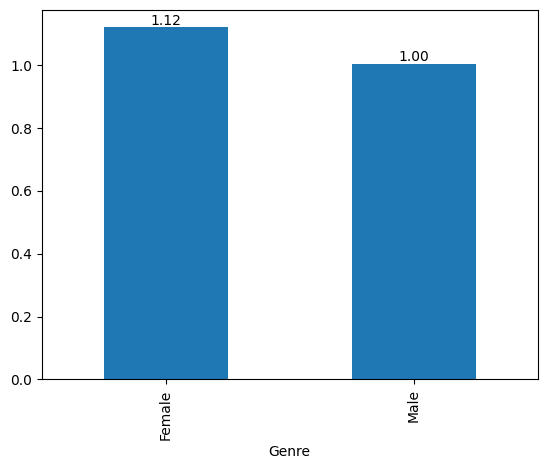

In [ ]:
ax = mall_df.groupby('Genre')['Propensity to Spend'].mean().plot(kind='bar')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

Menambahkan kolom baru Propensity to Spend — rasio antara skor belanja dan pendapatan. Nilai tinggi berarti pelanggan membelanjakan banyak relatif terhadap pendapatannya (boros), nilai rendah berarti hemat.

In [ ]:
mall_df.head(5)

,Genre,Age,Annual Income (k$),Spending Score (1-100),Propensity to Spend
0,Male,19,15,39,2.60
1,Male,21,15,81,5.40
2,Female,20,16,6,0.38
3,Female,23,16,77,4.81
4,Female,31,17,40,2.35


#Encoding

In [ ]:
gender_map = {
    'Female':0,
    'Male':1
}

mall_df['Genre'] = mall_df['Genre'].map(gender_map)

Mengubah nilai teks Female/Male menjadi angka 0/1 agar bisa diproses oleh algoritma machine learning yang hanya menerima input numerik.

#Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(mall_df)

 Melakukan standarisasi data agar semua fitur memiliki skala yang sama (mean=0, std=1). Ini penting agar fitur dengan nilai besar (seperti Annual Income) tidak mendominasi clustering.

#Elbow Method

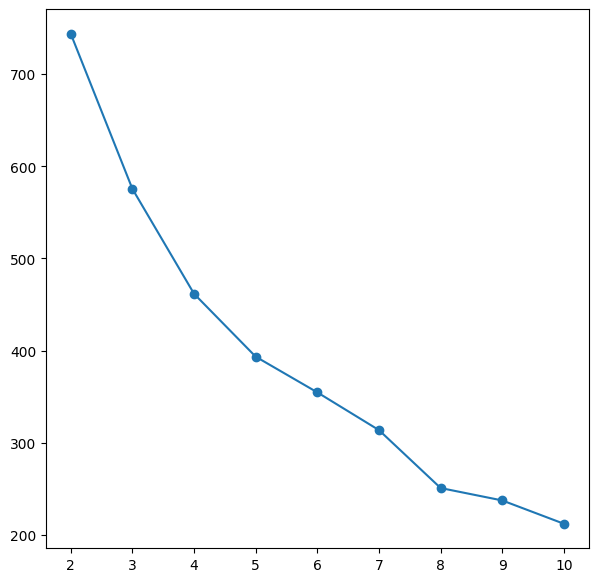

In [ ]:
from sklearn.cluster import KMeans

clusters_range = [2,3,4,5,6,7,8,9,10]
inertia = []

for c in clusters_range:
  kmeans = KMeans(n_clusters= c, random_state=42, init="k-means++").fit(X)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,7))
plt.plot(clusters_range, inertia, marker='o')

 Grafik garis yang menunjukkan nilai inertia (jumlah jarak kuadrat tiap titik ke centroid klusternya) untuk k=2 hingga k=10. Titik "siku" (elbow) di grafik menunjukkan jumlah cluster optimal. Dari notebook ini disimpulkan bahwa k=4 atau k=5 adalah kandidat awal karena penurunan inertia mulai melambat di situ.

#Silhouette Score

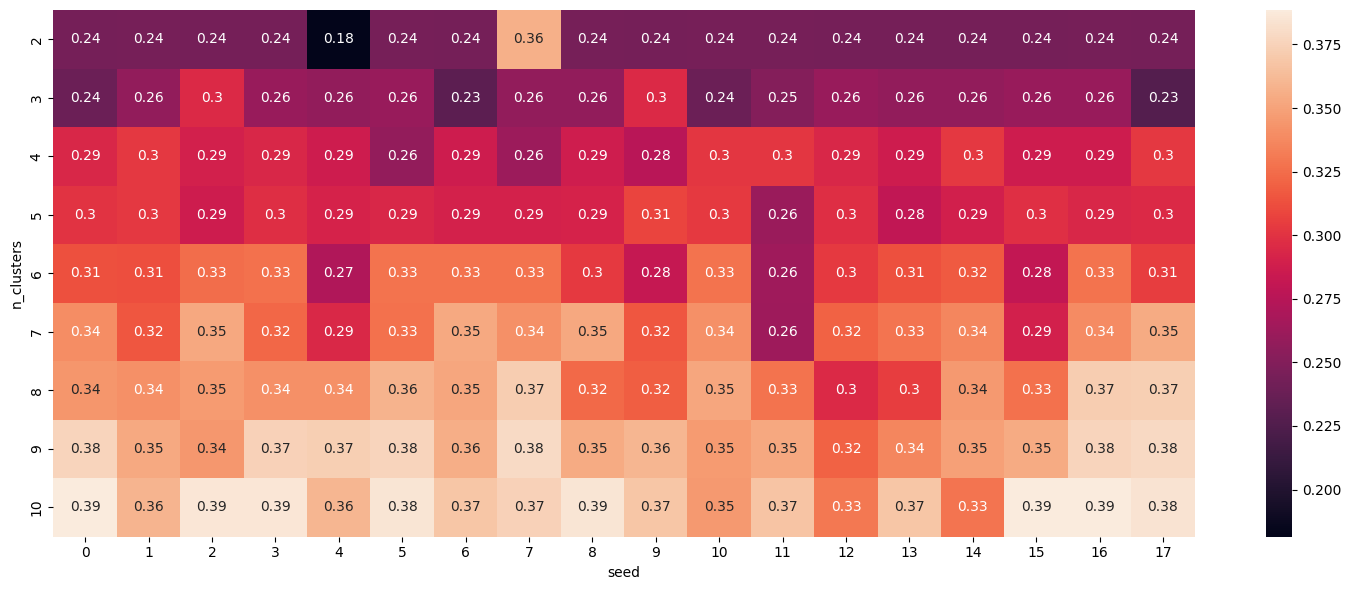

In [ ]:
from sklearn.metrics import silhouette_score

clusters_range = [2,3,4,5,6,7,8,9,10]
random_range = range(0,18)
results = []

for c in clusters_range:
  for r in random_range:
    clusterer = KMeans(n_clusters=c, random_state=r, init="k-means++")
    cluster_labels = clusterer.fit_predict(X)
    silhoutte_avg = silhouette_score(X, cluster_labels)
    results.append([c, r, silhoutte_avg])

result = pd.DataFrame(results, columns=("n_clusters", "seed", "silhouette_score"))

pivot = pd.pivot_table(result, index="n_clusters", columns="seed", values="silhouette_score")

plt.figure(figsize=(15,6))
sns.heatmap(pivot, annot=True)
plt.tight_layout()

Heatmap yang menampilkan nilai Silhouette Score untuk kombinasi jumlah cluster (k=2–10) dan berbagai random seed (0–17). Nilai Silhouette mendekati 1 artinya cluster terbentuk dengan baik (data dalam cluster rapat, antar cluster berjauhan). Kesimpulan dari notebook: k=6–7 paling stabil di berbagai seed.

#Davies Bouldin Score

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

clusters_range = [2,3,4,5,6,7,8,9,10]
random_range = range(0,18)
results = []

for c in clusters_range:
  for r in random_range:
    clusterer = KMeans(n_clusters=c, random_state=r, init="k-means++")
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    dbi = davies_bouldin_score(X, cluster_labels)

    results.append([c, r, silhouette_avg, dbi])

result = pd.DataFrame(results, columns=("n_clusters", "seed", "silhouette_score", "dbi"))

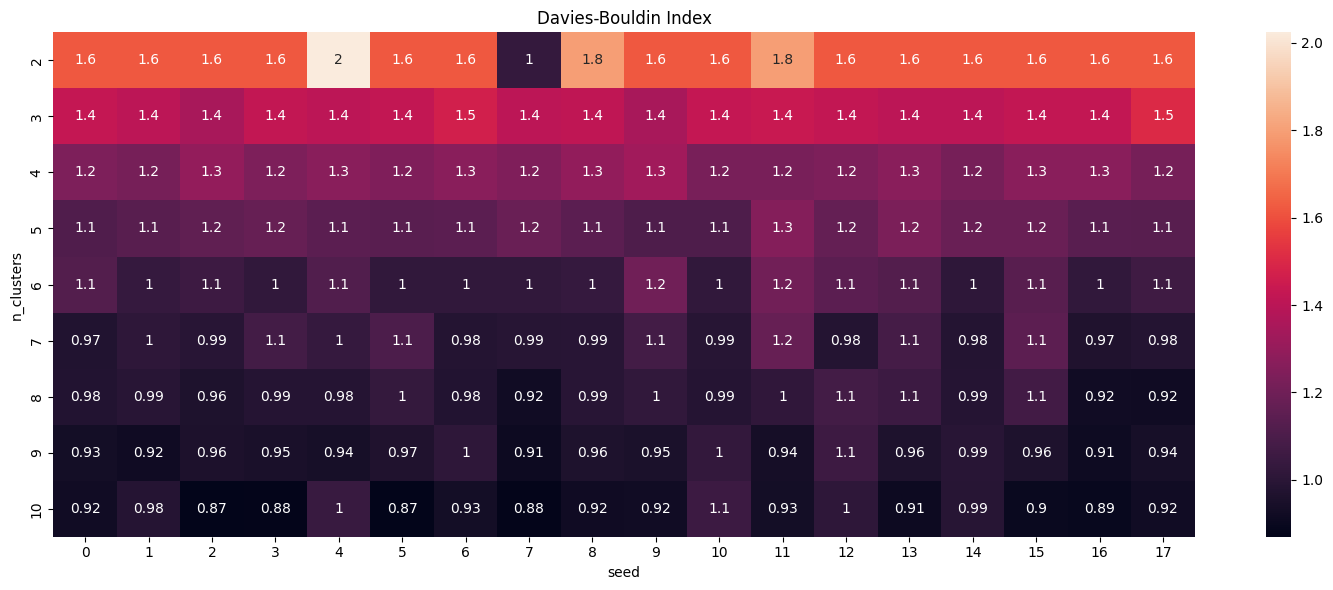

In [ ]:
pivot_dbi = pd.pivot_table(result, index="n_clusters", columns="seed", values="dbi")

plt.figure(figsize=(15,6))
sns.heatmap(pivot_dbi, annot=True)
plt.title("Davies-Bouldin Index")
plt.tight_layout()

 Heatmap DBI untuk k=2–10 di berbagai seed. DBI yang lebih rendah lebih baik (cluster lebih kompak dan terpisah). Kesimpulan: k=8–10 memberikan DBI terkecil, namun k=7 sudah cukup rendah (~0.97–1.1).

#Calinski Harabasz Score

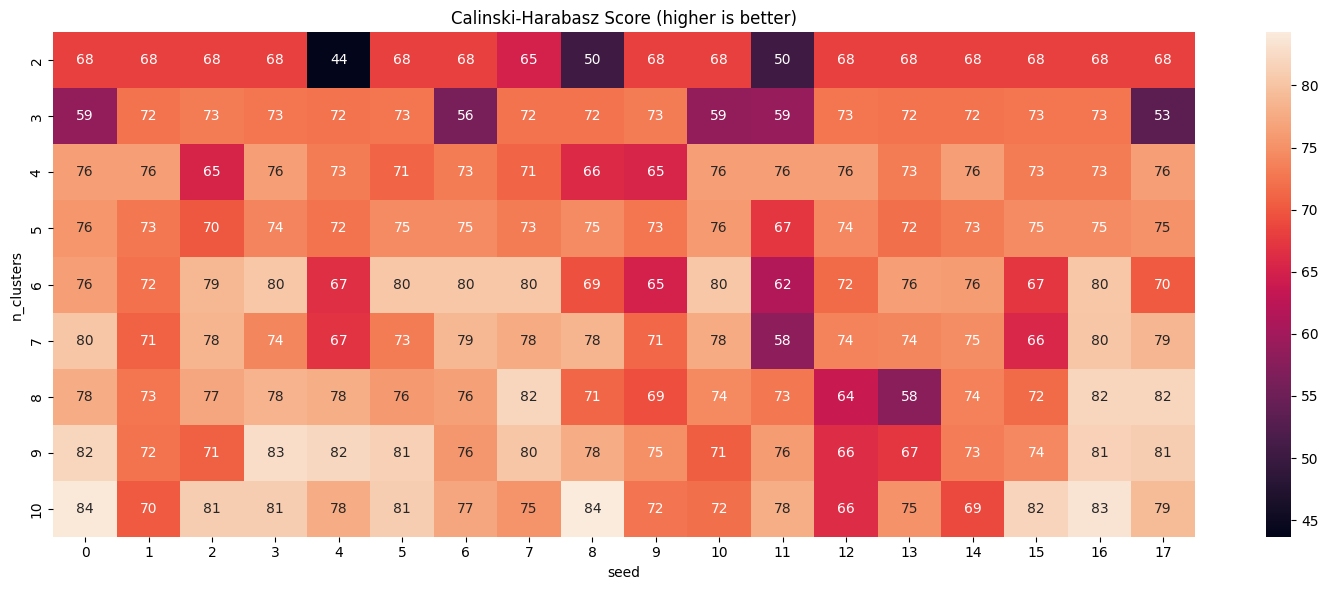

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

clusters_range = [2,3,4,5,6,7,8,9,10]
random_range = range(0,18)
results = []

for c in clusters_range:
  for r in random_range:
    clusterer = KMeans(n_clusters=c, random_state=r, init="k-means++")
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    dbi = davies_bouldin_score(X, cluster_labels)
    ch = calinski_harabasz_score(X, cluster_labels)

    results.append([c, r, silhouette_avg, dbi, ch])

result = pd.DataFrame(results, columns=("n_clusters", "seed", "silhouette_score", "dbi", "ch_score"))
pivot_ch = pd.pivot_table(result, index="n_clusters", columns="seed", values="ch_score")

plt.figure(figsize=(15,6))
sns.heatmap(pivot_ch, annot=True)
plt.title("Calinski-Harabasz Score (higher is better)")
plt.tight_layout()

Heatmap CH Score. Nilai semakin tinggi semakin baik. Namun nilainya cenderung terus naik seiring bertambahnya k, sehingga tidak bisa dipakai sendirian sebagai acuan.

Kandidat K awal
- k = 9–10 → terlalu granular (overfitting, sulit interpretasi)
- k = 6–7 → titik pas

#Perbadingan tiap Cluster

In [ ]:
k_values = [4,5,6,7,8,9,10]
results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, init="k-means++")
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    results.append([k, sil, dbi, ch])

eval_df = pd.DataFrame(results, columns=["k", "silhouette", "dbi", "ch_score"])
eval_df

,k,silhouette,dbi,ch_score
0,4,0.301944,1.223502,76.201838
1,5,0.295387,1.133203,75.196700
2,6,0.301087,1.083694,70.639332
3,7,0.303321,1.117711,70.424223
4,8,0.371691,0.922209,81.995267
5,9,0.352690,0.995304,76.786179
6,10,0.369324,0.994881,78.536407


In [ ]:
eval_df["rank_sil"] = eval_df["silhouette"].rank(ascending=False)
eval_df["rank_dbi"] = eval_df["dbi"].rank(ascending=True)
eval_df["rank_ch"] = eval_df["ch_score"].rank(ascending=False)

eval_df["final_score"] = eval_df[["rank_sil","rank_dbi","rank_ch"]].mean(axis=1)

eval_df.sort_values("final_score")

,k,silhouette,dbi,ch_score,rank_sil,rank_dbi,rank_ch,final_score
4,8,0.371691,0.922209,81.995267,1.0,1.0,1.0,1.000000
6,10,0.369324,0.994881,78.536407,2.0,2.0,2.0,2.000000
5,9,0.352690,0.995304,76.786179,3.0,3.0,3.0,3.000000
0,4,0.301944,1.223502,76.201838,5.0,7.0,4.0,5.333333
2,6,0.301087,1.083694,70.639332,6.0,4.0,6.0,5.333333
3,7,0.303321,1.117711,70.424223,4.0,5.0,7.0,5.333333
1,5,0.295387,1.133203,75.196700,7.0,6.0,5.0,6.000000


K = 8 dipilih sebagai jumlah cluster optimal karena memberikan keseimbangan terbaik antar metrik evaluasi. Nilai Silhouette Score yang tinggi menunjukkan pemisahan cluster yang baik, Davies-Bouldin Index yang rendah menandakan cluster yang kompak dan minim overlap, serta Calinski-Harabasz Score yang tinggi mengindikasikan struktur cluster yang jelas. Dengan demikian, K = 8 memberikan hasil yang optimal tanpa over-segmentation.

In [ ]:
results_df = mall_df.copy()

# K=6
kmeans_6 = KMeans(n_clusters=6, random_state=42, init='k-means++')
results_df['Cluster_6'] = kmeans_6.fit_predict(X)

# K=7
kmeans_7 = KMeans(n_clusters=7, random_state=42, init='k-means++')
results_df['Cluster_7'] = kmeans_7.fit_predict(X)

# K=8
kmeans_8 = KMeans(n_clusters=8, random_state=42, init='k-means++')
results_df['Cluster_8'] = kmeans_8.fit_predict(X)

results_df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Propensity to Spend,Cluster_6,Cluster_7,Cluster_8
0,1,19,15,39,2.60,5,5,2
1,1,21,15,81,5.40,2,2,2
2,0,20,16,6,0.38,1,1,4
3,0,23,16,77,4.81,2,2,2
4,0,31,17,40,2.35,1,2,4


In [ ]:
import plotly.graph_objects as go

colors = [
    '#e8000b',
    '#1ac938',
    '#023eff',
    '#ff7c00',
    '#8b2be2',
    '#00c2a0',
    '#ff1493',
    '#8b4513'
]

def plot_clusters(df, label_col, k):

    fig = go.Figure()

    for i in range(k):

        cluster_data = df[df[label_col] == i].copy()

        cluster_data['Gender_Code'] = cluster_data['Genre'].map({
            0: "Female",
            1: "Male"
        })

        customdata = cluster_data[
            ['Propensity to Spend', 'Gender_Code', label_col]
        ].to_numpy()

        fig.add_trace(
            go.Scatter3d(
                x=cluster_data['Age'],
                y=cluster_data['Annual Income (k$)'],
                z=cluster_data['Spending Score (1-100)'],

                mode='markers',

                marker=dict(
                    size=5,
                    color=colors[i],
                    opacity=0.7
                ),

                name=f'Cluster {i}',

                customdata=customdata,

                hovertemplate=
                    "Cluster: %{customdata[2]}<br>"
                    "Gender: %{customdata[1]}<br>"
                    "Age: %{x}<br>"
                    "Income: %{y}<br>"
                    "Spending Score: %{z}<br>"
                    "Propensity: %{customdata[0]}<br>"
                    "<extra></extra>"
            )
        )

    fig.update_layout(
        title=f'3D Clustering (K={k})',
        scene=dict(
            xaxis_title='Age',
            yaxis_title='Income',
            zaxis_title='Spending Score'
        ),
        width=1000,
        height=800
    )

    fig.show()

In [ ]:
plot_clusters(results_df, 'Cluster_6', 6)

In [ ]:
plot_clusters(results_df, 'Cluster_7', 7)

In [ ]:
plot_clusters(results_df, 'Cluster_8', 8)

In [ ]:
print(results_df['Cluster_6'].value_counts().sort_index())

print(results_df['Cluster_7'].value_counts().sort_index())

print(results_df['Cluster_8'].value_counts().sort_index())

Cluster_6
0    35
1    55
2    14
3    39
4    35
5    22
Name: count, dtype: int64
Cluster_7
0    31
1    33
2    14
3    39
4    31
5    14
6    38
Name: count, dtype: int64
Cluster_8
0    28
1    15
2    20
3    21
4    32
5    30
6    34
7    20
Name: count, dtype: int64


In [ ]:
results_df.groupby('Cluster_6').mean(numeric_only=True)

,Genre,Age,Annual Income (k$),Spending Score (1-100),Propensity to Spend,Cluster_7,Cluster_8
Cluster_6,,,,,,,
0,0.742857,59.514286,47.285714,41.171429,0.852000,1.542857,1.542857
1,0.000000,37.090909,49.254545,42.672727,0.901273,3.563636,4.909091
2,0.142857,25.000000,23.571429,81.571429,3.787143,2.214286,2.285714
3,0.461538,32.692308,86.538462,82.128205,0.977949,3.000000,3.923077
4,0.571429,41.685714,88.228571,17.285714,0.197143,3.714286,4.428571
5,1.000000,25.590909,43.409091,59.181818,1.649545,3.272727,3.454545


In [ ]:
results_df.groupby('Cluster_7').mean(numeric_only=True)

,Genre,Age,Annual Income (k$),Spending Score (1-100),Propensity to Spend,Cluster_6,Cluster_8
Cluster_7,,,,,,,
0,1.000000,56.000000,49.741935,39.451613,0.792903,0.709677,0.838710
1,0.212121,26.151515,56.242424,47.333333,0.873030,1.848485,4.212121
2,0.071429,25.642857,23.357143,78.785714,3.672857,1.928571,2.428571
3,0.461538,32.692308,86.538462,82.128205,0.977949,3.000000,3.923077
4,0.548387,40.419355,90.000000,15.741935,0.172581,4.000000,4.290323
5,1.000000,24.785714,31.428571,66.071429,2.322857,4.785714,2.714286
6,0.000000,50.973684,46.894737,40.421053,0.866316,0.842105,5.710526


In [ ]:
results_df.groupby('Cluster_8').mean(numeric_only=True)

,Genre,Age,Annual Income (k$),Spending Score (1-100),Propensity to Spend,Cluster_6,Cluster_7
Cluster_8,,,,,,,
0,1.0,56.535714,46.178571,40.035714,0.853929,0.357143,0.178571
1,0.0,44.600000,92.333333,21.600000,0.234667,4.000000,4.133333
2,0.5,25.050000,23.550000,78.600000,3.543000,3.200000,3.350000
3,0.0,32.190476,86.047619,81.666667,0.968571,3.000000,3.000000
4,0.0,27.812500,49.781250,45.750000,1.007187,1.062500,1.562500
5,1.0,29.533333,74.433333,70.966667,0.990667,3.800000,2.700000
6,0.0,52.205882,47.852941,42.176471,0.875882,0.735294,6.000000
7,1.0,39.500000,85.150000,14.050000,0.169000,4.000000,3.400000


## Perbandingan Kandidat Jumlah Cluster

| Aspek | K=6 | K=7 | K=8 |
|--------|--------|--------|--------|
| Silhouette | 0.301 | 0.303 | **0.372** |
| DBI | **1.084** | 1.118 | **0.922** |
| CH Score | **70.639** | 70.424 | **81.995** |
| Distribusi Cluster | Cukup Seimbang | **Paling Seimbang** | Mulai Terfragmentasi |
| Cluster Terkecil | 14 | 14 | 15 |
| Cluster Terbesar | 55 | 39 | 34 |
| Kemudahan Interpretasi | **Tinggi** | Tinggi | Sedang |
| Risiko Over-segmentation | Rendah | Rendah-Sedang | Tinggi |
| Kesesuaian untuk Segmentasi Pelanggan | Baik | **Sangat Baik** | Baik |

## Kesimpulan Pemilihan Jumlah Cluster

Berdasarkan evaluasi menggunakan Silhouette Score, Davies-Bouldin Index (DBI), dan Calinski-Harabasz Score (CH), nilai terbaik diperoleh pada K=8. Namun, evaluasi lanjutan terhadap distribusi anggota cluster menunjukkan bahwa K=8 menghasilkan beberapa cluster berukuran relatif kecil sehingga segmentasi menjadi lebih rinci dan berpotensi mengalami over-segmentation.

Sebaliknya, K=7 menghasilkan distribusi anggota cluster yang lebih seimbang dibandingkan K=6 maupun K=8. Selain itu, jumlah cluster yang dihasilkan masih cukup mudah untuk diinterpretasikan dan digunakan dalam penyusunan strategi segmentasi pelanggan.

Oleh karena itu, penelitian ini memilih K=7 sebagai jumlah cluster optimal karena memberikan keseimbangan terbaik antara kualitas metrik clustering, distribusi anggota cluster yang merata, serta kemudahan interpretasi hasil segmentasi.

In [ ]:
results_df.drop(columns=['Cluster_6', 'Cluster_8'], inplace=True)
results_df.rename(columns={'Cluster_7': 'Labels'}, inplace=True)

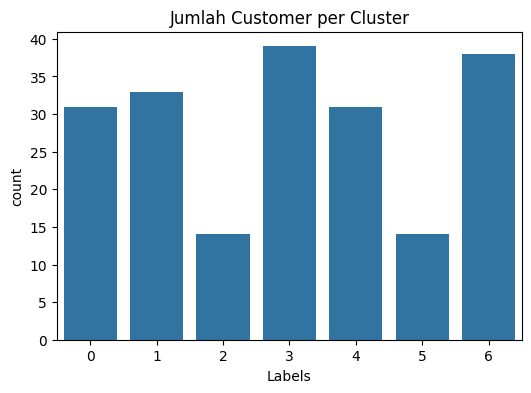

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Labels", data=results_df)
plt.title("Jumlah Customer per Cluster")
plt.show()

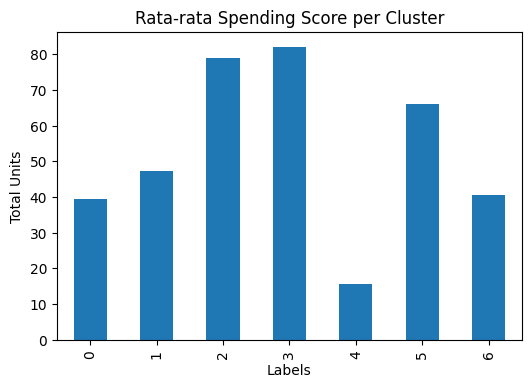

In [ ]:
cluster_volume = results_df.groupby("Labels")["Spending Score (1-100)"].mean()

cluster_volume.plot(kind="bar", figsize=(6,4))
plt.title("Rata-rata Spending Score per Cluster")
plt.ylabel("Total Units")
plt.show()

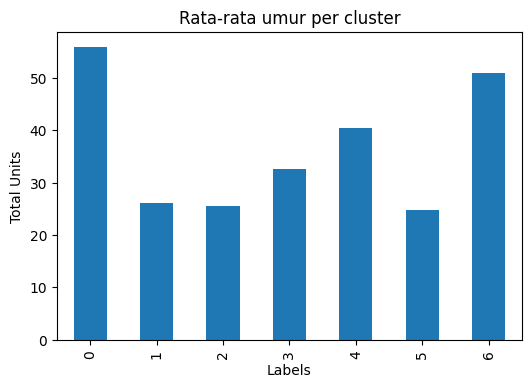

In [ ]:
cluster_volume = results_df.groupby("Labels")["Age"].mean()

cluster_volume.plot(kind="bar", figsize=(6,4))
plt.title("Rata-rata umur per cluster")
plt.ylabel("Total Units")
plt.show()

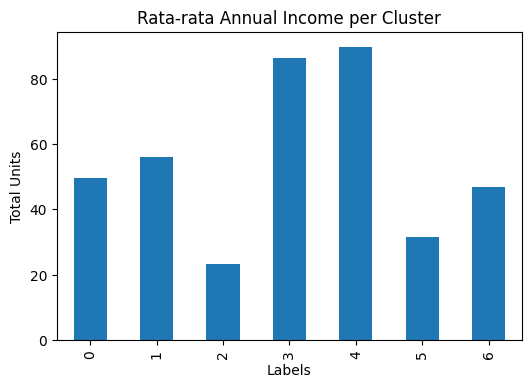

In [ ]:
cluster_volume = results_df.groupby("Labels")["Annual Income (k$)"].mean()

cluster_volume.plot(kind="bar", figsize=(6,4))
plt.title("Rata-rata Annual Income per Cluster")
plt.ylabel("Total Units")
plt.show()

In [ ]:
group = results_df.groupby('Labels')[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Propensity to Spend']].mean()
print(group)

           Genre        Age  Annual Income (k$)  Spending Score (1-100)  \
Labels                                                                    
0       1.000000  56.000000           49.741935               39.451613   
1       0.212121  26.151515           56.242424               47.333333   
2       0.071429  25.642857           23.357143               78.785714   
3       0.461538  32.692308           86.538462               82.128205   
4       0.548387  40.419355           90.000000               15.741935   
5       1.000000  24.785714           31.428571               66.071429   
6       0.000000  50.973684           46.894737               40.421053   

        Propensity to Spend  
Labels                       
0                  0.792903  
1                  0.873030  
2                  3.672857  
3                  0.977949  
4                  0.172581  
5                  2.322857  
6                  0.866316  


# Customer Segmentation Analysis

### Cluster 0 — Male, Older, Low–Medium Spender
- **Gender**: Male  
- **Usia**: Tua (~56)  
- **Income**: Sedang (~50k)  
- **Spending Score**: Rendah (~39)  
- **Insight**:  
  Pria usia tua dengan tingkat pengeluaran relatif rendah → cenderung berbelanja berdasarkan kebutuhan dan kurang konsumtif

---

### Cluster 1 — Female-Dominant, Young Adult, Average Spender
- **Gender**: Campuran (condong female)  
- **Usia**: Muda (~26)  
- **Income**: Sedang (~56k)  
- **Spending Score**: Sedang (~47)  
- **Insight**:  
  Pelanggan muda dengan pendapatan dan pengeluaran yang seimbang → segmen pelanggan umum yang potensial untuk program loyalitas

---

### Cluster 2 — Female, Young, High Spender
- **Gender**: Female  
- **Usia**: Sangat muda (~26)  
- **Income**: Rendah (~23k)  
- **Spending Score**: Tinggi (~79)  
- **Insight**:  
  Anak muda dengan income rendah tetapi konsumtif → impulsive buyer dan responsif terhadap promosi

---

### Cluster 3 — High Income, High Spender (VIP)
- **Gender**: Campuran  
- **Usia**: Dewasa muda (~33)  
- **Income**: Tinggi (~87k)  
- **Spending Score**: Sangat tinggi (~82)  
- **Insight**:  
  Segmen terbaik dengan pendapatan dan pengeluaran tinggi → high value customer / VIP

---

### Cluster 4 — High Income, Very Low Spender
- **Gender**: Campuran (sedikit condong female)  
- **Usia**: Dewasa (~40)  
- **Income**: Sangat tinggi (~90k)  
- **Spending Score**: Sangat rendah (~16)  
- **Insight**:  
  Memiliki daya beli tinggi namun jarang berbelanja → berpotensi ditingkatkan melalui promo premium yang lebih personal

---

### Cluster 5 — Male, Young Adult, Medium–High Spender
- **Gender**: Male  
- **Usia**: Sangat muda (~25)  
- **Income**: Rendah–Sedang (~31k)  
- **Spending Score**: Tinggi (~66)  
- **Insight**:  
  Pria muda dengan pengeluaran relatif tinggi dibanding pendapatannya → cocok untuk produk lifestyle dan hiburan

---

### Cluster 6 — Female, Older, Low–Medium Spender
- **Gender**: Female  
- **Usia**: Tua (~51)  
- **Income**: Sedang (~47k)  
- **Spending Score**: Rendah (~40)  
- **Insight**:  
  Wanita usia tua dengan pola belanja konservatif → lebih mempertimbangkan manfaat dan nilai produk sebelum membeli

In [ ]:
results_df.to_csv('clustering_mall_7.csv')

#KLASIFIKASI

In [ ]:
class_df = pd.read_csv('/content/clustering_mall_7.csv')

In [ ]:
class_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              200 non-null    int64  
 1   Genre                   200 non-null    int64  
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
 5   Propensity to Spend     200 non-null    float64
 6   Labels                  200 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 11.1 KB


In [ ]:
class_df.head(5)

,Unnamed: 0,Genre,Age,Annual Income (k$),Spending Score (1-100),Propensity to Spend,Labels
0,0,1,19,15,39,2.60,5
1,1,1,21,15,81,5.40,2
2,2,0,20,16,6,0.38,1
3,3,0,23,16,77,4.81,2
4,4,0,31,17,40,2.35,2


In [ ]:
class_df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
class_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Genre                   200 non-null    int64  
 1   Age                     200 non-null    int64  
 2   Annual Income (k$)      200 non-null    int64  
 3   Spending Score (1-100)  200 non-null    int64  
 4   Propensity to Spend     200 non-null    float64
 5   Labels                  200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    class_df,
    test_size=0.10,
    random_state=42,
    stratify=class_df["Labels"]
)

X_train = train_df.drop("Labels", axis=1)
y_train = train_df["Labels"]

X_test = test_df.drop("Labels", axis=1)
y_test = test_df["Labels"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        C=1,
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

pipeline_lr.fit(X_train, y_train)

y_pred = pipeline_lr.predict(X_test)

y_proba = pipeline_lr.predict_proba(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr',
    average='weighted'
)

print("\nSUMMARY METRICS")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         4

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.94        20
weighted avg       0.97      0.95      0.95        20


Confusion Matrix:
[[3 0 0 0 0 0 0]
 [0 2 0 0 0 1 0]
 [0 0 1 0 0 0 0]
 [0 0 0 4 0 0 0]
 [0 0 0 0 3 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 4]]

SUMMARY METRICS
Accuracy : 0.9500 (95.00%)
Precision: 0.9667
Recall   : 0.9500
F1-Score : 0.9500
ROC AUC  : 0.9971


In [ ]:
import joblib

In [ ]:
joblib.dump(pipeline_lr, "logistic_regression_pipeline.pkl")

['logistic_regression_pipeline.pkl']